# Task 2: Interpolation

From the analysis we know that returns are approximately stationary, data exhibit no seasonality, weak autocorrelation in returns, strong volatility clustering, and some cross-series correlation.

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.structural import UnobservedComponents

df = pd.read_csv("../Data/processed_data.csv")

# Removing last 200 values
df = df.iloc[:-200]

# If no date column exists, use integer time index
df.index = np.arange(len(df))

assets = [
    "gurkor", "guitars", "slingshots",
    "stocks", "sugar", "water", "tranquillity"
]

log_prices = np.log(df[assets])


## Data inspection

Zoom each asset around its **single internal** missing block of **50** consecutive points. Only raw levels from `df` are plotted—no imputation yet—so NaNs appear as gaps in the blue line.

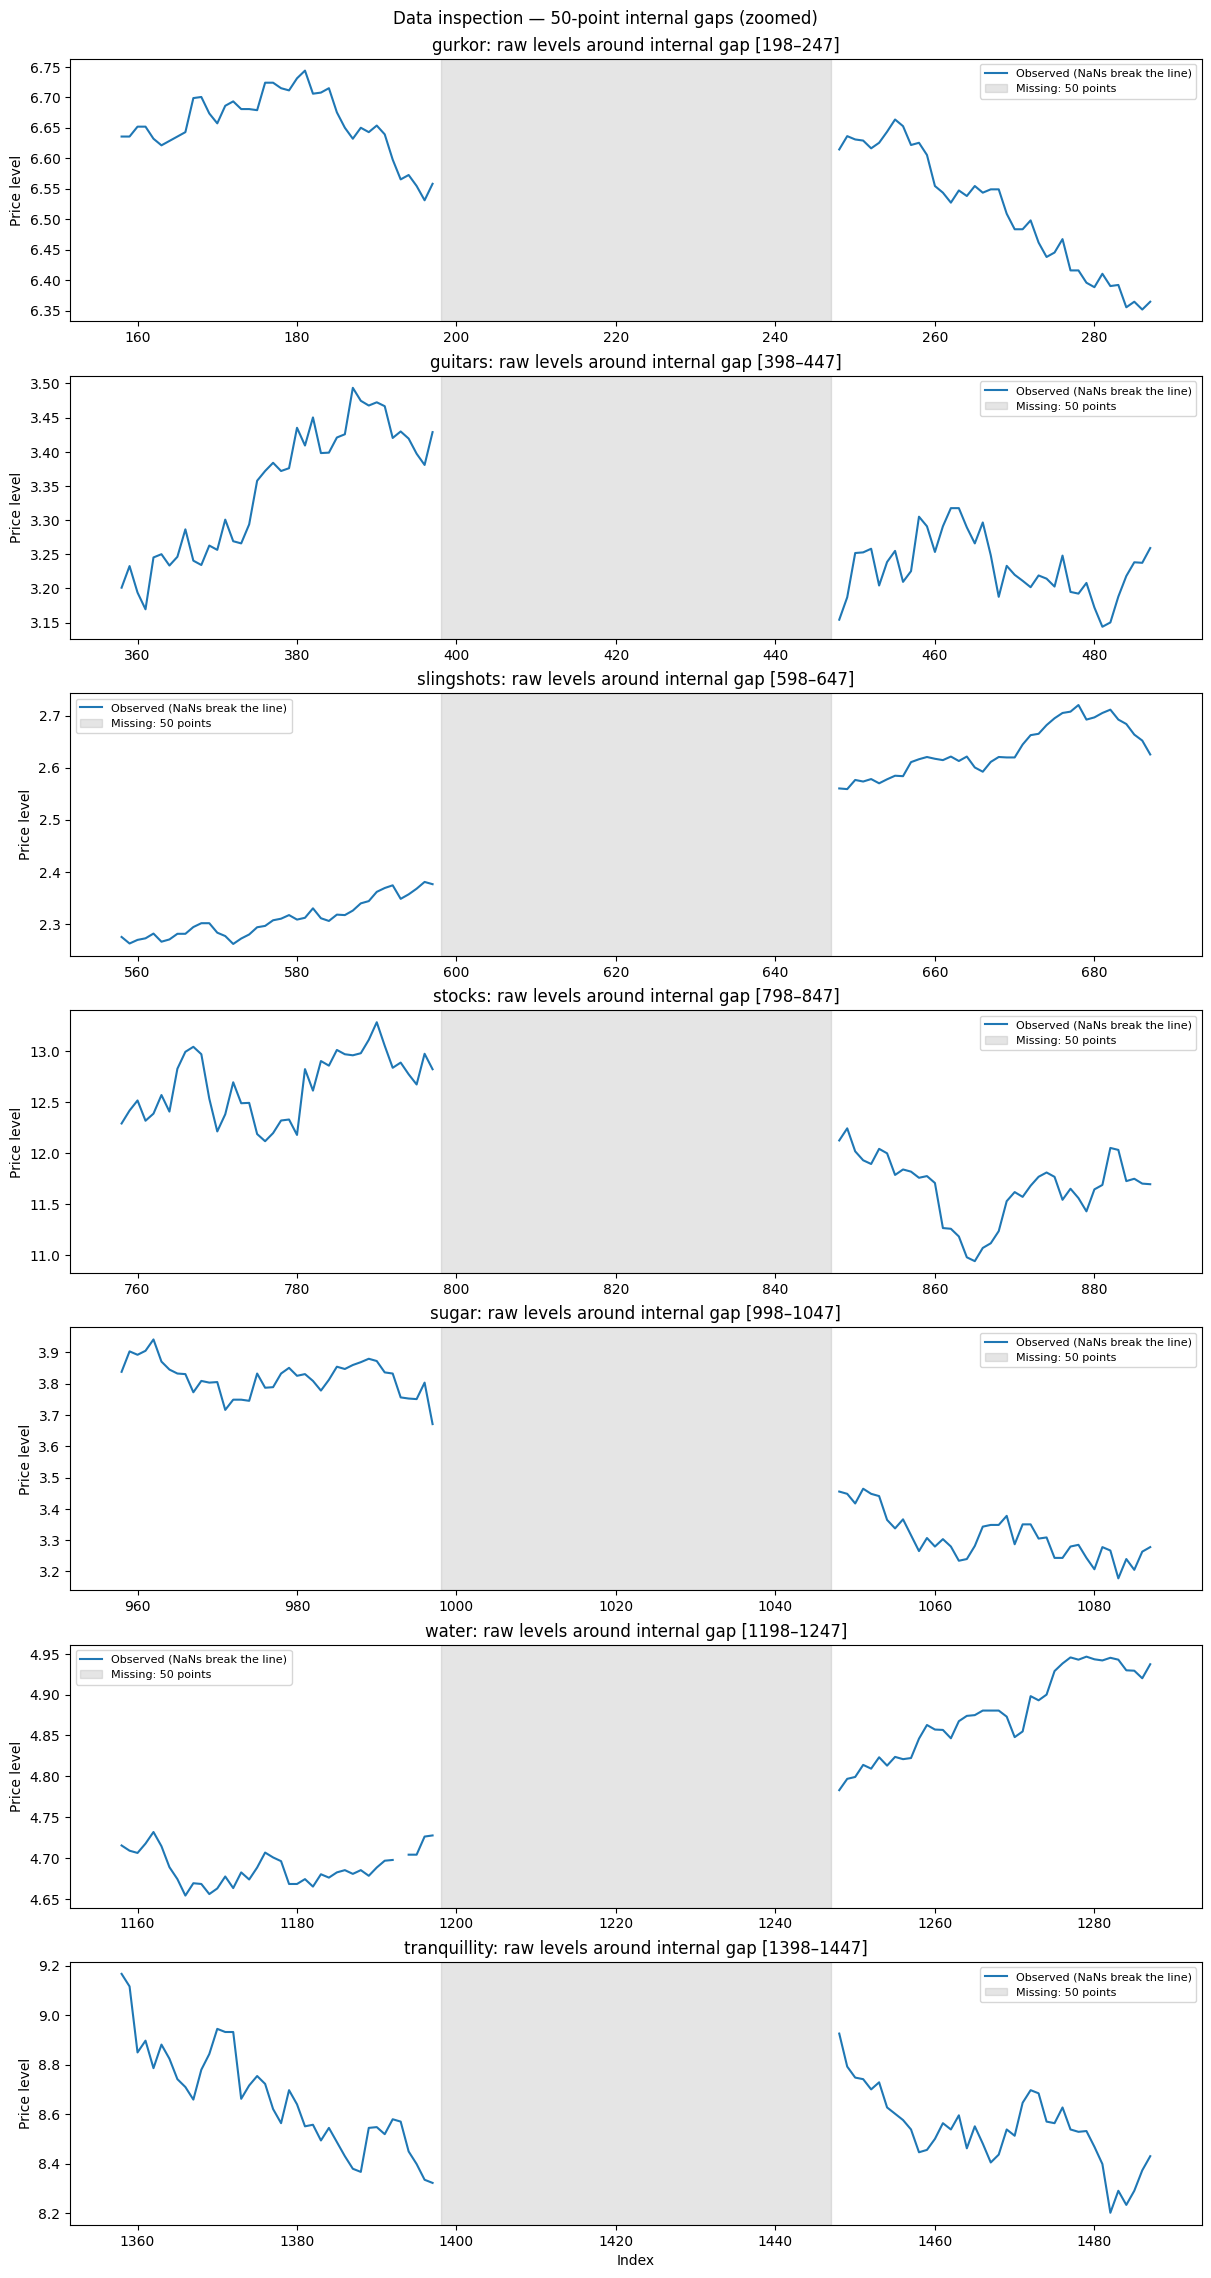

In [44]:
INTERNAL_GAP_LEN = 50
ZOOM_PAD = 40


def internal_nan_runs(s: pd.Series):
    """Return (start, end) inclusive positional indices for internal NaN blocks."""
    x = s.isna().to_numpy()
    if not x.any():
        return []
    padded = np.concatenate([[False], x, [False]])
    diff = np.diff(padded.astype(int))
    starts = np.where(diff == 1)[0]
    ends = np.where(diff == -1)[0] - 1
    runs = []
    for a, b in zip(starts, ends):
        if a > 0 and b < len(s) - 1:
            runs.append((a, b))
    return runs


def main_internal_gap_run(s: pd.Series, length: int = INTERNAL_GAP_LEN):
    """Single internal missing stretch of exactly `length` points, or None."""
    candidates = [
        (a, b) for a, b in internal_nan_runs(s)
        if (b - a + 1) == length
    ]
    if len(candidates) != 1:
        return None
    return candidates[0]


def plot_internal_gaps_raw_inspection(pad: int = ZOOM_PAD):
    """One subplot per asset: zoom around the sole 50-point internal NaN run (raw levels only)."""
    panels = []
    for asset in assets:
        series = df[asset].astype(float)
        run = main_internal_gap_run(series, INTERNAL_GAP_LEN)
        if run is None:
            continue
        panels.append((asset, series, run))

    if not panels:
        print(
            f"No series with exactly one internal NaN run of length {INTERNAL_GAP_LEN}. "
            "Nothing to plot."
        )
        return

    n = len(panels)
    fig, axes = plt.subplots(
        n, 1, figsize=(12, 3.2 * n), sharex=False, constrained_layout=True
    )
    if n == 1:
        axes = np.array([axes])

    for ax, (asset, series, (a, b)) in zip(axes, panels):
        idx = series.index.to_numpy()
        lo = max(idx.min(), idx[a] - pad)
        hi = min(idx.max(), idx[b] + pad)
        mask = (idx >= lo) & (idx <= hi)

        ax.plot(
            idx[mask],
            series.to_numpy()[mask],
            label="Observed (NaNs break the line)",
            lw=1.5,
            color="C0",
        )
        ax.axvspan(
            idx[a],
            idx[b],
            color="gray",
            alpha=0.2,
            label=f"Missing: {INTERNAL_GAP_LEN} points",
        )
        ax.set_title(
            f"{asset}: raw levels around internal gap [{int(idx[a])}–{int(idx[b])}]"
        )
        ax.set_ylabel("Price level")
        ax.legend(loc="best", fontsize=8)

    axes[-1].set_xlabel("Index")
    fig.suptitle(
        "Data inspection — 50-point internal gaps (zoomed)", fontsize=12, y=1.01
    )
    plt.show()


plot_internal_gaps_raw_inspection()


## Models

- Random-walk bridge - Strong baseline and uses both endpoints without overfitting
- Linear interpolation in log-price	- Equivalent/simple version of bridge expectation
- ARIMA on log-returns - Tests whether return autocorrelation helps
- ARIMAX / dynamic regression - Uses related assets, e.g. gurkor-water, guitars-slingshots
- Local level state-space model / Kalman smoother - Very suitable for missing financial price observations
- GARCH / ARIMA-GARCH simulation - Task 1 found volatility clustering; helps intervals
- VAR on returns - Useful if lead-lag/correlation exists, but likely weak

In [45]:
def score_prediction(true, pred, lower=None, upper=None):
    out = {
        "RMSE": np.sqrt(mean_squared_error(true, pred)),
        "MAE": mean_absolute_error(true, pred)
    }

    if lower is not None and upper is not None:
        out["coverage_95"] = np.mean((true >= lower) & (true <= upper))
        out["avg_width_95"] = np.mean(upper - lower)

    return out

### Random-walk Bridge

Our baseline model. This is just linear interpolation in log-price.

In [46]:
def rw_bridge_fill(series):
    return series.interpolate(method="linear")

def rw_bridge_mc(series, gap_start, gap_end, n_sim=1000):
    """
    Simulates random-walk bridge paths between observed endpoints.
    gap_start inclusive, gap_end exclusive.
    """
    y = series.copy()
    left = y.iloc[gap_start - 1]
    right = y.iloc[gap_end]

    gap_len = gap_end - gap_start

    returns = y.diff().dropna()
    sigma = returns.std()

    sims = np.zeros((n_sim, gap_len))

    for s in range(n_sim):
        increments = np.random.normal(0, sigma, gap_len + 1)

        raw_path = left + np.cumsum(increments)

        # force bridge to end at right endpoint
        adjustment = np.linspace(0, right - raw_path[-1], gap_len + 1)
        bridge_path = raw_path + adjustment

        sims[s, :] = bridge_path[:-1]

    mean = sims.mean(axis=0)
    lower = np.percentile(sims, 2.5, axis=0)
    upper = np.percentile(sims, 97.5, axis=0)

    return mean, lower, upper

### ARIMA on returns

In [47]:
def arima_forward_fill(series, gap_start, gap_end, order=(1, 0, 1), n_sim=1000):
    y = series.copy()
    train = y.copy()
    train.iloc[gap_start:gap_end] = np.nan

    observed = train.dropna()
    returns = observed.diff().dropna()

    gap_len = gap_end - gap_start
    left = y.iloc[gap_start - 1]

    try:
        model = ARIMA(returns, order=order).fit()
        forecast = model.get_forecast(steps=gap_len)
        mean_ret = forecast.predicted_mean.values

        sim_returns = model.simulate(
            nsimulations=gap_len,
            repetitions=n_sim,
            anchor="end"
        )

        sim_returns = np.asarray(sim_returns)

        if sim_returns.shape[0] == gap_len:
            sim_returns = sim_returns.T

    except Exception:
        mu = returns.mean()
        sigma = returns.std()
        mean_ret = np.repeat(mu, gap_len)
        sim_returns = np.random.normal(mu, sigma, size=(n_sim, gap_len))

    mean_path = left + np.cumsum(mean_ret)

    sim_paths = left + np.cumsum(sim_returns, axis=1)

    mean = sim_paths.mean(axis=0)
    lower = np.percentile(sim_paths, 2.5, axis=0)
    upper = np.percentile(sim_paths, 97.5, axis=0)

    return mean, lower, upper

### Cross-series Regression

Explicitly use correlation structure.

In [48]:
from sklearn.linear_model import LinearRegression

correlated_predictors = {
    "gurkor": ["water"],
    "water": ["gurkor"],
    "guitars": ["slingshots"],
    "slingshots": ["guitars"],
    "sugar": ["slingshots", "guitars", "tranquillity"],
    "tranquillity": ["guitars", "slingshots", "sugar"],
    "stocks": []
}

def cross_series_fill_mc(log_prices, asset, gap_start, gap_end, n_sim=1000, alpha=1.0):
    predictors = correlated_predictors.get(asset, [])

    if len(predictors) == 0:
        mean = rw_bridge_fill(log_prices[asset]).iloc[gap_start:gap_end].values
        resid_sigma = log_prices[asset].diff().std()
        sims = np.random.normal(mean, resid_sigma, size=(n_sim, len(mean)))
        return mean, np.percentile(sims, 2.5, axis=0), np.percentile(sims, 97.5, axis=0)

    data = log_prices.copy()

    y = data[asset].copy()
    y.iloc[gap_start:gap_end] = np.nan

    X = data[predictors].copy()
    X = X.interpolate(method="linear")

    train_mask = y.notna() & X.notna().all(axis=1)

    model = Ridge(alpha=alpha)
    model.fit(X.loc[train_mask], y.loc[train_mask])

    pred_idx = y.index[gap_start:gap_end]
    X_gap = X.loc[pred_idx]

    mean = model.predict(X_gap)

    residuals = y.loc[train_mask] - model.predict(X.loc[train_mask])
    resid_sigma = residuals.std()

    sims = mean + np.random.normal(0, resid_sigma, size=(n_sim, len(mean)))

    lower = np.percentile(sims, 2.5, axis=0)
    upper = np.percentile(sims, 97.5, axis=0)

    return mean, lower, upper

### Kalman Smoother

In [49]:
from statsmodels.tsa.statespace.structural import UnobservedComponents

def kalman_fill_mc(series, gap_start, gap_end, n_sim=1000):
    y = series.copy()
    y.iloc[gap_start:gap_end] = np.nan

    try:
        model = UnobservedComponents(y, level="local level")
        res = model.fit(disp=False)

        pred = res.get_prediction()
        mean_full = pred.predicted_mean
        ci = pred.conf_int(alpha=0.05)

        mean = mean_full.iloc[gap_start:gap_end].values
        lower = ci.iloc[gap_start:gap_end, 0].values
        upper = ci.iloc[gap_start:gap_end, 1].values

        return mean, lower, upper

    except Exception:
        filled = rw_bridge_fill(y)
        mean = filled.iloc[gap_start:gap_end].values
        sigma = series.diff().std()
        sims = np.random.normal(mean, sigma, size=(n_sim, len(mean)))

        return mean, np.percentile(sims, 2.5, axis=0), np.percentile(sims, 97.5, axis=0)

## Backtesting

In [50]:
def sample_valid_gap(series, gap_len, rng, min_buffer=5):
    n = len(series)

    for _ in range(500):
        start = rng.integers(min_buffer, n - gap_len - min_buffer)
        end = start + gap_len

        # Need full block + both endpoints observed
        if series.iloc[start-1:end+1].notna().all():
            return start, end

    return None, None

def backtest_asset(log_prices, asset, gap_lengths, n_trials=50, n_sim=1000, seed=123):
    rng = np.random.default_rng(seed)
    series = log_prices[asset]

    rows = []
    import time
    t0 = time.time()
    done = 0
    # total planned iterations (gap_lengths × n_trials)
    total = len(gap_lengths) * n_trials

    for gap_len in gap_lengths:
        for trial in range(n_trials):
            start, end = sample_valid_gap(series, gap_len, rng)

            if start is None:
                continue

            true = series.iloc[start:end].values

            methods = {}

            # 1. random-walk bridge
            mean, lower, upper = rw_bridge_mc(series, start, end, n_sim=n_sim)
            methods["rw_bridge"] = (mean, lower, upper)

            # 2. ARIMA
            mean, lower, upper = arima_forward_fill(series, start, end, n_sim=n_sim)
            methods["arima"] = (mean, lower, upper)

            # 3. cross-series regression
            mean, lower, upper = cross_series_fill_mc(log_prices, asset, start, end, n_sim=n_sim)
            methods["cross_series_ridge"] = (mean, lower, upper)

            # 4. Kalman smoother
            mean, lower, upper = kalman_fill_mc(series, start, end, n_sim=n_sim)
            methods["kalman_local_level"] = (mean, lower, upper)

            done += 1
            if done % 5 == 0:  # print every 5 completed trials
                elapsed = time.time() - t0
                rate = elapsed / done
                eta = rate * (total - done)
                print(
                    f"{asset} | done {done}/{total} "
                    f"({done/total:.0%}) | elapsed {elapsed/60:.1f} min | ETA {eta/60:.1f} min"
                )

            for method, (pred, lower, upper) in methods.items():
                score = score_prediction(true, pred, lower, upper)

                rows.append({
                    "asset": asset,
                    "gap_len": gap_len,
                    "trial": trial,
                    "start": start,
                    "end": end,
                    "method": method,
                    **score
                })

    return pd.DataFrame(rows)

gap_lengths = [10, 25, 50, 100]

all_bt = []

for asset in assets:
    res = backtest_asset(
        log_prices=log_prices,
        asset=asset,
        gap_lengths=gap_lengths,
        n_trials=50,
        n_sim=1000,
        seed=123
    )
    all_bt.append(res)

bt_results = pd.concat(all_bt, ignore_index=True)

/home/oliverodhe/other/TMS088/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/oliverodhe/other/TMS088/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/oliverodhe/other/TMS088/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/oliverodhe/other/TMS088/venv/lib/python3.12/site-packages/statsmodels/base/mode

## Full Run

In [51]:
summary = (
    bt_results
    .groupby(["asset", "method"])
    [["RMSE", "MAE", "coverage_95", "avg_width_95"]]
    .mean()
    .sort_values(["asset", "RMSE"])
)

summary

best_method_per_asset = (
    bt_results
    .groupby(["asset", "method"])["RMSE"]
    .mean()
    .reset_index()
    .sort_values(["asset", "RMSE"])
    .groupby("asset")
    .first()
)

best_method_per_asset

best_by_gap = (
    bt_results
    .groupby(["asset", "gap_len", "method"])["RMSE"]
    .mean()
    .reset_index()
    .sort_values(["asset", "gap_len", "RMSE"])
    .groupby(["asset", "gap_len"])
    .first()
)

best_by_gap

method      RMSE
asset        gap_len                              
guitars      10                rw_bridge  0.017291
             25                rw_bridge  0.026618
             50                rw_bridge  0.039556
             100               rw_bridge  0.045699
gurkor       10                rw_bridge  0.004906
             25                rw_bridge  0.006959
             50                rw_bridge  0.010368
             100               rw_bridge  0.014680
slingshots   10                rw_bridge  0.016457
             25                rw_bridge  0.025843
             50                rw_bridge  0.033370
             100               rw_bridge  0.045670
stocks       10       cross_series_ridge  0.000000
             25       cross_series_ridge  0.000000
             50       cross_series_ridge  0.000000
             100      cross_series_ridge  0.000000
sugar        10                rw_bridge  0.015675
             25                rw_bridge  0.025391
             50                rw_bridge  0.035015
             100               rw_bridge  0.046626
tranquillity 10                rw_bridge  0.016000
             25                rw_bridge  0.022437
             50                rw_bridge  0.030191
             100               rw_bridge  0.048176
water        10                rw_bridge  0.004965
             25                rw_bridge  0.007001
             50                rw_bridge  0.009115
             100               rw_bridge  0.013274

##Key Discussion Points

### Data properties (from Task 1)
- Log-returns show little autocorrelation → weak predictability in the mean
- No seasonality detected → no need for seasonal models
- Volatility clustering present → uncertainty varies over time
- Some correlation between assets, but limited predictive power
### Model comparison
- Random-walk bridge (linear interpolation in log-prices) consistently performs best
- ARIMA does not improve results → returns behave close to white noise
- Kalman smoother performs similarly but does not outperform baseline
- Cross-series regression provides little or no improvement overall
### Interpretation
- Data behaves approximately like a random walk in the mean
- Under a random-walk assumption, linear interpolation is the optimal estimator
- More complex models cannot extract signal that is not present in the data
### Effect of gap size
- RMSE increases with gap length for all assets
- Larger gaps → higher uncertainty → worse interpolation accuracy
- Relationship is monotonic and consistent across series
### Role of volatility
- Assets with higher volatility have larger interpolation errors
- Interpolation difficulty is driven more by volatility than model choice
### Uncertainty
- Even with a good point estimate, uncertainty remains substantial
- Uncertainty is lowest near endpoints and highest in the middle of gaps
- This matches the theoretical variance of a random-walk bridge
### Overall conclusion
- The random-walk bridge is both:
    - empirically best-performing
    - theoretically justified
- More complex models do not provide meaningful improvements
- The main limitation is the inherent unpredictability of the data, not the method used